# The mediator on a proton-transfer scan

`docs/fff_v2.md` §8. Two dimers, each with a shared hydrogen and therefore two defensible
fragmentations:

| system | partition A | partition B |
| --- | --- | --- |
| H5O2+ (Zundel) | `H3O+ \| H2O` | `H2O \| H3O+` |
| H3O2- | `H2O \| OH-` | `OH- \| H2O` |

The O-O distance is held near its equilibrium value and the shared proton is scanned along the
axis. At each point we evaluate **both expert surfaces separately** (the pure vertices) and the
**mediated mixture**, and plot what each says.

Three figures:

1. **Energy components** - one pane per channel, because their scales differ by two orders of
   magnitude. Thin lines with markers are the two vertices; the thick line is the mixture.
2. **Emitted parameters** for the shared hydrogen - the quantities §8 mixes *at the parameter
   level*, so this is the picture of what "a `C6` is a `C6`" actually buys.
3. **The membership** `pi` against the transfer coordinate, with the validity envelopes that
   gate it.

Colour is by channel throughout: **blue** electrostatics, **red** Pauli, **green** dispersion,
**purple** induction, **black** total. Identity never rests on colour alone - the two vertices
are separated by marker and the mixture by line weight - so the figures survive greyscale and
colour-vision deficiency.

In [1]:
%matplotlib inline

import math
import os
import sys
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/rsfff_matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

torch.set_default_dtype(torch.float64)

from rsfff.ff.mediator import MediatorHead
from rsfff.ff.mixture_model import MixtureGroup, intra_pairs_unsorted, mixture_forward
from rsfff.ff.units import KJMOL_PER_HARTREE
from rsfff.mlip.reference_states import AtomicStateReference
from rsfff.train.build_expert import build_expert_model
from rsfff.train.data import Batch, load_reference_energies

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e8ef",
    "grid.linewidth": 0.7,
    "axes.labelcolor": "#20242c",
    "axes.edgecolor": "#aeb4c0",
    "xtick.color": "#3c4450",
    "ytick.color": "#3c4450",
    "font.size": 9,
})

FIGDIR = Path("notebooks/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ---- knobs -------------------------------------------------------------------------------
CHECKPOINT = "checkpoints/ion_mediator_v4_full/best.pt"   # v4: state key + soft partition
N_SCAN = 41          # points along the transfer coordinate
MARKEVERY = 4        # marker stride, so the thin vertex lines stay readable

# Channel -> colour. Fixed by meaning, never cycled: a channel keeps its hue in every figure.
CHANNEL_COLOR = {
    "elst": "#1f4fd8",        # blue
    "pauli": "#d1263c",       # red
    "disp": "#1a8f43",        # green
    "induction": "#7b3fbf",   # purple
    "total": "#111418",       # black
}

# The two vertices are separated by MARKER, not by colour, so every pane stays legible in
# greyscale and under colour-vision deficiency. The mixture is separated by line WEIGHT.
VERTEX_MARKER = ("o", "s")
VERTEX_STYLE = dict(lw=1.0, markersize=3.6, markerfacecolor="none", markeredgewidth=0.9, alpha=0.95)
MIX_STYLE = dict(lw=2.6, alpha=0.95, solid_capstyle="round")

INK = "#20242c"
MUTED = "#6b7280"

In [3]:
# ---- geometries --------------------------------------------------------------------------
def _unit(theta_deg, phi_deg, axis_sign=1.0):
    """Unit vector at `theta` from the (signed) O-O axis, azimuth `phi`."""
    t, p = math.radians(theta_deg), math.radians(phi_deg)
    return np.array([axis_sign * math.cos(t),
                     math.sin(t) * math.cos(p),
                     math.sin(t) * math.sin(p)])


def zundel(r_oo, d, r_oh=0.98, theta=112.0):
    """H5O2+, atom order [O1 H H | O2 H H | H_bridge]. Bridge sits at x = d on the axis.

    The four terminal hydrogens point *away* from the other oxygen, which is the Zundel
    geometry; they are held fixed through the scan so the only thing moving is the proton.
    """
    o1, o2 = np.zeros(3), np.array([r_oo, 0.0, 0.0])
    pos = [o1]
    pos += [o1 + r_oh * _unit(theta, phi, -1.0) for phi in (60.0, 300.0)]
    pos += [o2]
    pos += [o2 + r_oh * _unit(theta, phi, +1.0) for phi in (120.0, 240.0)]
    pos += [np.array([d, 0.0, 0.0])]
    return np.array(pos), np.array([8, 1, 1, 8, 1, 1, 1])


def hydroxide_dimer(r_oo, d, r_oh=0.97, theta=105.0):
    """H3O2-, atom order [O1 H | O2 H | H_bridge]."""
    o1, o2 = np.zeros(3), np.array([r_oo, 0.0, 0.0])
    pos = [o1,
           o1 + r_oh * _unit(theta, 90.0, -1.0),
           o2,
           o2 + r_oh * _unit(theta, 270.0, +1.0),
           np.array([d, 0.0, 0.0])]
    return np.array(pos), np.array([8, 1, 8, 1, 1])


#: `r_oo` is held near equilibrium (Zundel ~2.40 A, H3O2- ~2.45 A) so the scan is a pure
#: proton transfer rather than a simultaneous compression.
SYSTEMS = {
    "H5O2+": dict(
        build=zundel, r_oo=2.40, bridge=6, o_pair=(0, 3),
        fragments=np.array([[0, 0, 0, 1, 1, 1, 0],
                            [0, 0, 0, 1, 1, 1, 1]]),
        charges=np.array([[1.0, 0.0], [0.0, 1.0]]),
        labels=("H3O+ | H2O", "H2O | H3O+"),
    ),
    "H3O2-": dict(
        build=hydroxide_dimer, r_oo=2.45, bridge=4, o_pair=(0, 2),
        fragments=np.array([[0, 0, 1, 1, 0],
                            [0, 0, 1, 1, 1]]),
        charges=np.array([[0.0, -1.0], [-1.0, 0.0]]),
        labels=("H2O | OH-", "OH- | H2O"),
    ),
}

In [4]:
# ---- the model ---------------------------------------------------------------------------
def load_mediated_model(checkpoint=CHECKPOINT):
    """Rebuild the trained model *including* its mediator, and load strictly.

    The mediator is attached at train time by `rsfff.train.train_expert._build_mixture_stream`,
    so `build_expert_model` alone does not produce it and a strict load would fail. Its slot
    widths are read off the model's own descriptor rather than recomputed from the feature
    config, because the fragment slot carries the appended `(Q_f, 2S_f, n_f)` state block and
    is wider than `feature_dims` says.
    """
    state = torch.load(checkpoint, map_location="cpu", weights_only=False)
    cfg = state["config"]
    nt = tuple(int(z) for z in state["neighbor_types"])
    e0 = load_reference_energies(cfg.data.reference_energies, nt).double()
    states = AtomicStateReference.from_json(
        cfg.data.atomic_reference_states, nt, dtype=torch.float64
    )
    model = build_expert_model(cfg, nt, e0, states).double()

    spec = SYSTEMS["H5O2+"]
    pos, Z = spec["build"](spec["r_oo"], 0.5 * spec["r_oo"])
    probe, _ = vertex_batch(pos, Z, spec["fragments"][0], spec["charges"][0])
    em = model.emit(probe, probe.fragment_idx)
    p_frag = int(em.iso.inv_feats.shape[-1])
    p_env = int(em.joined.inv_feats.shape[-1]) - p_frag

    model.mediator = MediatorHead(
        p_frag, p_env,
        hidden=cfg.expert.mediator_hidden,
        depth=cfg.expert.mediator_depth,
        bump=dict(lo0=0.0, lo1=0.0,
                  hi1=cfg.expert.mediator_bump_hi1,
                  hi0=cfg.expert.mediator_bump_hi0),
    ).double()
    model.load_state_dict(state["model_state"], strict=True)
    model.eval()
    return model, cfg, state


def vertex_batch(pos, Z, frag, q_frag):
    """A one-frame `Batch` for a single fragmentation, plus the permutation back.

    `FragmentExpertModel.forward` needs atoms grouped by fragment; the two partitions disagree
    about that grouping, so each is sorted independently and every per-atom result is mapped
    back to the shared atom order before anything is compared across partitions.
    """
    order = np.argsort(frag, kind="stable")
    inverse = np.empty_like(order)
    inverse[order] = np.arange(order.size)
    f = torch.as_tensor(frag[order])
    n_frag = int(f.max()) + 1
    batch = Batch(
        positions=torch.as_tensor(pos[order]),
        atomic_numbers=torch.as_tensor(Z[order]),
        batch_idx=torch.zeros(len(Z), dtype=torch.long),
        n_systems=1,
        energy=torch.zeros(1),
        fragment_idx=f,
        fragment_charge=torch.as_tensor(q_frag),
        fragment_two_s=torch.zeros(n_frag),
        fragment_to_batch=torch.zeros(n_frag, dtype=torch.long),
        n_fragments=n_frag,
    )
    return batch, torch.as_tensor(inverse)


model, cfg, state = load_mediated_model()
print(f"checkpoint : {CHECKPOINT}")
print(f"run_name   : {cfg.run_name}   epoch {state.get('epoch')}   val_loss {state.get('val_loss'):.6g}")
print(f"parameters : {sum(p.numel() for p in model.parameters())}   induction: {model.induction}")
print(f"state key  : dim {model.fragment_state.dim} over (Q, 2S) + {model.fragment_state.n_species} element counts")
print(f"mediator   : {sum(p.numel() for p in model.mediator.parameters())} parameters, "
      f"envelope hi1={model.mediator.bump['hi1']} hi0={model.mediator.bump['hi0']} A")

checkpoint : checkpoints/ion_mediator_v4_full/best.pt
run_name   : ion_mediator_v4_full   epoch 54   val_loss 2926.47
parameters : 249686   induction: True
state key  : dim 4 over (Q, 2S) + 2 element counts
mediator   : 19937 parameters, envelope hi1=1.5 hi0=2.2 A


In [5]:
# ---- one scan point ----------------------------------------------------------------------
def mixture_group(spec, pos, Z):
    """The `MixtureGroup` for one geometry: every partition, one shared atom order."""
    frag = spec["fragments"]
    atom_charge = torch.zeros(frag.shape[0], len(Z))
    for m in range(frag.shape[0]):
        atom_charge[m] = torch.as_tensor(spec["charges"][m])[torch.as_tensor(frag[m])]
    return MixtureGroup(
        positions=torch.as_tensor(pos),
        atomic_numbers=torch.as_tensor(Z),
        fragments=torch.as_tensor(frag),
        atom_charge=atom_charge,
        atom_two_s=torch.zeros_like(atom_charge),
        contested=torch.tensor([spec["bridge"]]),
    )


def vertex_record(model, spec, pos, Z, m):
    """Energies and emitted parameters for partition `m`, in the shared atom order."""
    batch, inverse = vertex_batch(pos, Z, spec["fragments"][m], spec["charges"][m])
    with torch.no_grad():
        out = model(batch, with_induction=True)
        em = model.emit(batch, batch.fragment_idx)
    unsort = lambda t: t[inverse]                                     # noqa: E731
    # The two O-H contacts the transfer is about, looked up in the sorted pair list and
    # reported in the shared atom order. `pair_frag >= 0` marks an intra pair, which is what
    # `b_ij` will soften.
    order = np.argsort(spec["fragments"][m], kind="stable")
    resort = torch.as_tensor(order)                                   # shared -> sorted
    def pair_energy(a, b):
        ia, ib = int(resort.tolist().index(a)), int(resort.tolist().index(b))
        lo, hi = min(ia, ib), max(ia, ib)
        hit = ((out.pair_index[0] == lo) & (out.pair_index[1] == hi)).nonzero()
        if hit.numel() == 0:
            return 0.0, 0.0
        k = int(hit[0])
        total = sum(float(v[k]) for v in out.e_pair.values())
        return total, float(out.is_intra[k])
    # v4: one shared decoder, read on the atom's own description. `em.iso` is `h` alone (with
    # the fragment-state block); `em.joined` would be the in-medium evaluation. The one-body
    # parameters plotted here are all isolated ones, so this asks for `iso` throughout.
    species = em.iso.species_idx
    c6, b_disp = model.decoder.dispersion(em.iso, species)
    poly, b_pauli = model._pauli_from(em.iso, species)
    r0_iso, _alpha = model.decoder.r0(species)
    rp = model.decode_response(
        batch, em.iso, species, batch.batch_idx,
        bond_index=intra_pairs_unsorted(batch.fragment_idx),
    )
    return dict(
        energy={
            "elst": float(out.interaction["elst"][0]),
            "pauli": float(out.interaction["pauli"][0]),
            "disp": float(out.interaction["disp"][0]),
            "induction": float(out.interaction["induction"][0]),
            "total": float(out.energy[0]),
        },
        bond_atom=unsort(out.energy_bond_atom),
        pairs={
            "O1-H": pair_energy(spec["o_pair"][0], spec["bridge"]),
            "O2-H": pair_energy(spec["o_pair"][1], spec["bridge"]),
        },
        totals={"bond": float(out.energy_bond.sum()),
                "intra": float(out.energy_intra.sum())},
        params={
            "q": unsort(out.response.charges),
            "Z": unsort(rp.z),
            "b_elec": unsort(rp.b),
            "eta": unsort(rp.eta),
            "q_pauli": unsort(poly[:, 0]),
            "b_pauli": unsort(b_pauli),
            "mu_pauli": unsort(poly[:, 1:4].norm(dim=-1)) if poly.shape[1] > 3 else unsort(torch.zeros_like(b_pauli)),
            "C6": unsort(c6),
            "b_disp": unsort(b_disp),
            **{f"r0_{k}": unsort(v) for k, v in r0_iso.items()},
        },
    )


def scan(name, n=N_SCAN, delta_window=None):
    """Scan the shared proton across the O-O axis at fixed R(O-O).

    `delta_window=(lo, hi)` restricts the scan to a range of the transfer coordinate
    `delta = r(O1-H) - r(O2-H)`, which is how the crossover is resolved: the trained mediator
    switches inside a few hundredths of an Angstrom, so the default grid puts about one point
    in the region that matters.
    """
    spec = SYSTEMS[name]
    r_oo = spec["r_oo"]
    if delta_window is None:
        # Keep the proton clear of either oxygen's covalent wall at both ends.
        d_grid = np.linspace(0.94, r_oo - 0.94, n)
    else:
        lo, hi = delta_window
        d_grid = np.linspace(0.5 * (r_oo + lo), 0.5 * (r_oo + hi), n)
    n_part = spec["fragments"].shape[0]

    rows = {"delta": [], "d": [], "weights": [], "omega": [],
            "vertex": [[] for _ in range(n_part)], "mix": []}
    for d in d_grid:
        pos, Z = spec["build"](r_oo, float(d))
        rows["d"].append(float(d))
        # The standard proton-transfer coordinate: r(O1-H) - r(O2-H), zero at the midpoint.
        rows["delta"].append(float(d - (r_oo - d)))

        for m in range(n_part):
            rows["vertex"][m].append(vertex_record(model, spec, pos, Z, m))

        group = mixture_group(spec, pos, Z)
        with torch.no_grad():
            mix = mixture_forward(model, group, model.mediator, with_induction=True)
        w = mix.mediator.weights
        rows["weights"].append(w.numpy().copy())
        rows["omega"].append(mix.mediator.omega.numpy().copy())
        def mix_pair(a, b):
            lo, hi = min(a, b), max(a, b)
            hit = ((mix.pair_index[0] == lo) & (mix.pair_index[1] == hi)).nonzero()
            if hit.numel() == 0:
                return 0.0, 0.0
            k = int(hit[0])
            return sum(float(v[k]) for v in mix.e_pair.values()), float(mix.b_ij[k])

        rows["mix"].append(dict(
            bond_atom=mix.energy_bond_atom,
            pairs={"O1-H": mix_pair(spec["o_pair"][0], spec["bridge"]),
                   "O2-H": mix_pair(spec["o_pair"][1], spec["bridge"])},
            totals={"bond": float(mix.energy_bond), "intra": float(mix.energy_intra)},
            energy={
                "elst": float(mix.energy_inter["elst"]),
                "pauli": float(mix.energy_inter["pauli"]),
                "disp": float(mix.energy_inter["disp"]),
                "induction": float(mix.energy_induction),
                "total": float(mix.energy),
            },
            # Decoded once from the mixed description -- not a weighted sum of two experts'
            # answers, which is the mixing level v2 used and v4 no longer has.
            params=_decoded_params(model, mix, group, spec),
        ))
    rows["delta"] = np.array(rows["delta"])
    rows["d"] = np.array(rows["d"])
    rows["weights"] = np.array(rows["weights"])
    rows["omega"] = np.array(rows["omega"])
    return rows


def _decoded_params(model, mix, group, spec):
    """The mixture's parameters, decoded from the **soft-partitioned description**.

    v2 formed these as `sum_m w_m theta_m` -- a weighted average of two experts' answers, which
    is what produced the crossover excursion. v3 decoded once from a mixed key. v4 decodes from
    the description built at the mixed *edge partition*: `h` and `eta` are the power spectra of
    `A(s)` and `A(1-s)`, which are genuine descriptors for every `s`, and the fragment state is
    the fractional `(Q*, 2S*, n*)`. So what comes out is a parameter set the decoder would emit
    for some real input rather than an average of two incompatible ones.

    `mix.emission` is that description, carried on the output precisely so this does not have
    to rebuild the partition. Rebuilding it here is how a notebook silently drifts from the
    model it is plotting.
    """
    em = mix.emission
    species = em.iso.species_idx
    c6, b_disp = model.decoder.dispersion(em.iso, species)
    poly, b_pauli = model._pauli_from(em.iso, species)
    r0_iso, _ = model.decoder.r0(species)
    rp = model.decode_response(
        group.batch(0), em.iso, species, torch.zeros_like(species),
        bond_index=em.channels,
    )
    return {
        "q": mix.charges,
        "Z": rp.z, "b_elec": rp.b, "eta": rp.eta,
        "q_pauli": poly[:, 0], "b_pauli": b_pauli,
        "mu_pauli": poly[:, 1:4].norm(dim=-1) if poly.shape[1] > 3 else torch.zeros_like(b_pauli),
        "C6": c6, "b_disp": b_disp,
        **{f"r0_{k}": v for k, v in r0_iso.items()},
    }


scans = {name: scan(name) for name in SYSTEMS}
for name, s in scans.items():
    print(f"{name}: {len(s['d'])} points, delta {s['delta'][0]:+.2f} to {s['delta'][-1]:+.2f} A, "
          f"w range {s['weights'].min():.3f}-{s['weights'].max():.3f}")

H5O2+: 41 points, delta -0.52 to +0.52 A, w range 0.003-0.997
H3O2-: 41 points, delta -0.57 to +0.57 A, w range 0.005-0.995


## 1. Energy components

One pane per channel. The scales genuinely differ - electrostatics and Pauli run to hundreds of
kJ/mol while dispersion is a few - so they get separate axes rather than a shared one; a second
y-axis would be the wrong answer here and a shared one would flatten dispersion into the
baseline.

Thin lines with open markers are the **pure vertices**, each evaluated entirely on its own
expert surface. The thick line is the **mediated mixture**. Where the two vertices separate,
the thick line shows which one the mediator is keeping.

The total pane is plotted relative to the lowest point on the scan, since the absolute total is
~-153 Ha and the structure is a few tens of kJ/mol on top of it.

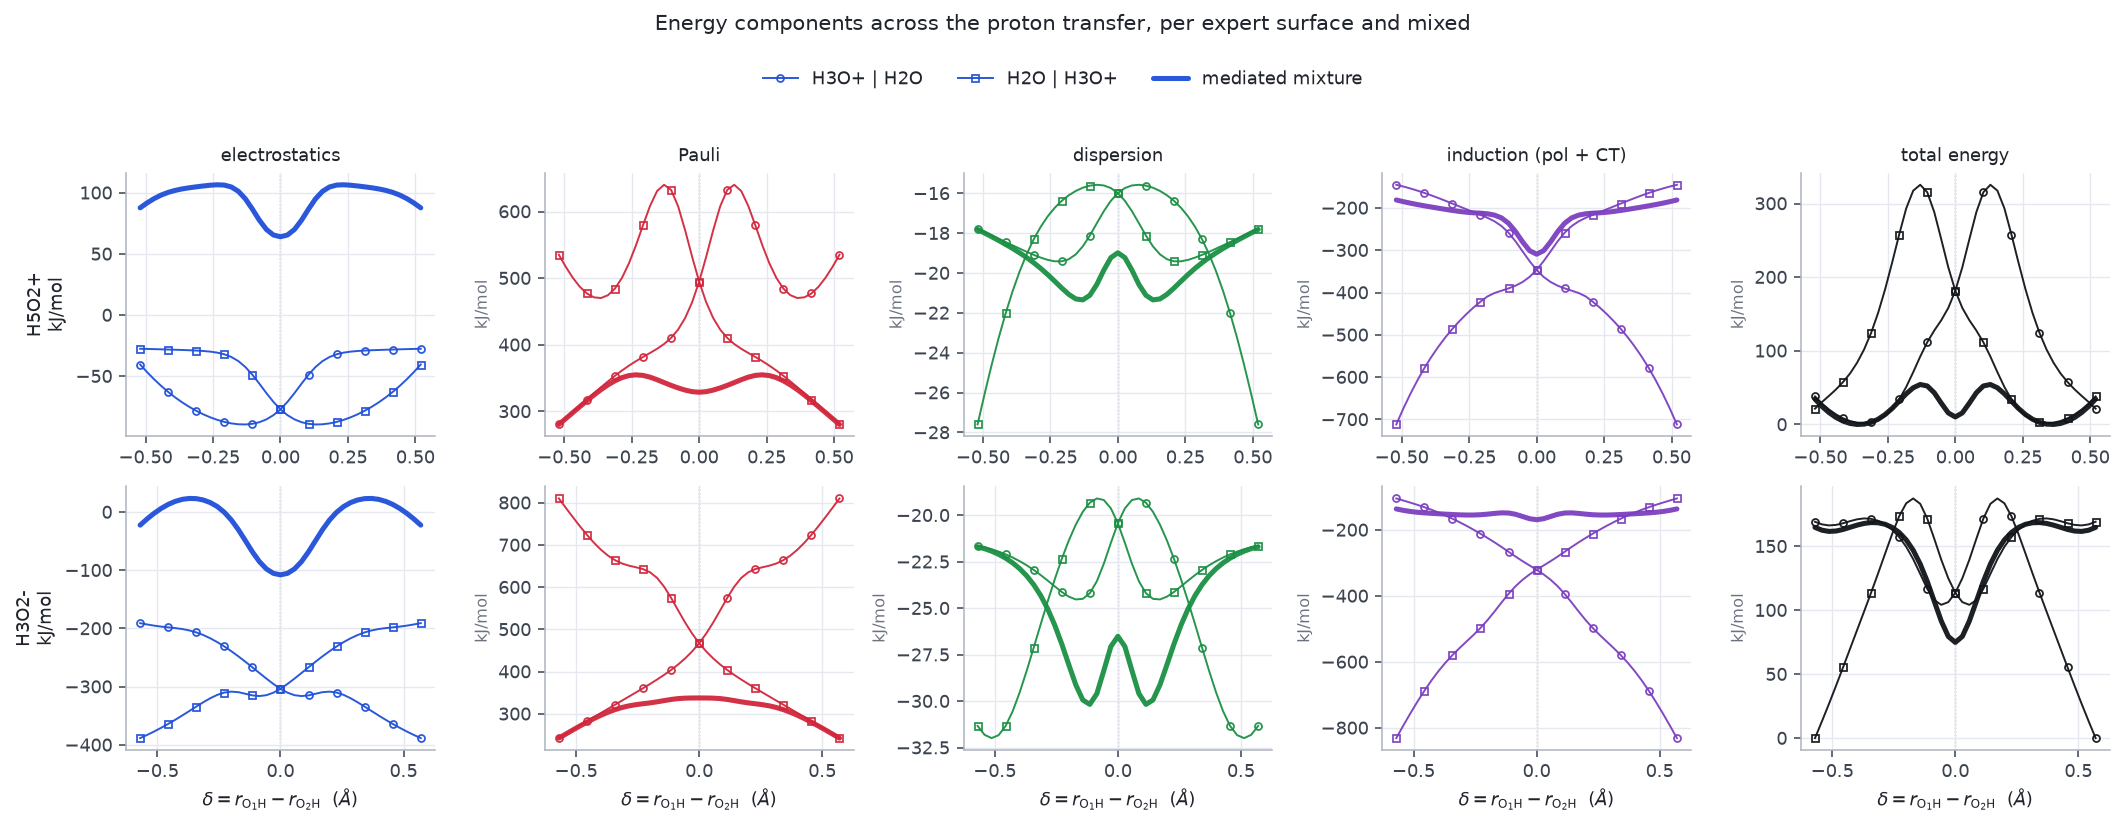

In [6]:
CHANNELS = [("elst", "electrostatics"), ("pauli", "Pauli"), ("disp", "dispersion"),
            ("induction", "induction (pol + CT)"), ("total", "total energy")]


def energy_figure(scans, save=True):
    n_rows, n_cols = len(scans), len(CHANNELS)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.05 * n_cols, 2.65 * n_rows))
    axes = np.atleast_2d(axes)

    for r, (name, s) in enumerate(scans.items()):
        spec = SYSTEMS[name]
        x = s["delta"]
        n_part = spec["fragments"].shape[0]
        for c, (key, title) in enumerate(CHANNELS):
            ax = axes[r, c]
            color = CHANNEL_COLOR[key]
            series = []
            for m in range(n_part):
                series.append(np.array([v["energy"][key] for v in s["vertex"][m]]) * KJMOL_PER_HARTREE)
            mixed = np.array([v["energy"][key] for v in s["mix"]]) * KJMOL_PER_HARTREE

            if key == "total":
                floor = min(min(v.min() for v in series), mixed.min())
                series = [v - floor for v in series]
                mixed = mixed - floor

            for m in range(n_part):
                ax.plot(x, series[m], color=color, marker=VERTEX_MARKER[m],
                        markevery=MARKEVERY, label=spec["labels"][m] if (r == 0 and c == 0) else None,
                        **VERTEX_STYLE)
            ax.plot(x, mixed, color=color,
                    label="mediated mixture" if (r == 0 and c == 0) else None, **MIX_STYLE)

            ax.axvline(0.0, color=MUTED, lw=0.7, ls=":", zorder=0)
            if r == 0:
                ax.set_title(title, color=INK, fontsize=9.5, pad=6)
            if c == 0:
                ax.set_ylabel(f"{name}\nkJ/mol", color=INK)
            else:
                ax.set_ylabel("kJ/mol", color=MUTED, fontsize=8)
            if r == n_rows - 1:
                ax.set_xlabel(r"$\delta = r_{\mathrm{O_1H}} - r_{\mathrm{O_2H}}$  ($\AA$)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    # One legend for the whole figure: identity is marker + weight, so repeating it per pane
    # would be noise. Legend text stays in ink, never in a series colour.
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 1.045), labelcolor=INK)
    fig.suptitle("Energy components across the proton transfer, per expert surface and mixed",
                 y=1.10, fontsize=11, color=INK)
    fig.tight_layout()
    if save:
        fig.savefig(FIGDIR / "mediator_energy_components.png", bbox_inches="tight")
    return fig


energy_figure(scans);

## 2. Emitted parameters at the shared hydrogen

The quantities §8 mixes **at the parameter level**, all read at the isolated evaluation
`theta_0 = P(h, 0)` - what each expert claims about its own fragment, with no environment term.

This is the picture of what the parameter tier actually buys. `Z` and `b` are per-element,
per-expert *constants*, so each vertex is a flat line at a different height - the H3O+ expert
and the H2O expert simply disagree about what a hydrogen's Slater exponent is - and the thick
line interpolates between them. Nothing about that interpolation is a network output; it is a
weighted average of two numbers that mean the same thing, which is exactly the claim.

`r0` and `C6` are feature-dependent and so curve with the geometry.

Two atoms are shown per system, for opposite reasons. The **shared hydrogen** is described by
the *same* expert in both partitions -- in H5O2+ it belongs to the hydronium either way -- so
its per-element constants are identical between the vertices and only the feature-dependent
quantities move. **O1** is where the expert genuinely changes: hydronium oxygen under one
partition, water oxygen under the other.

/var/folders/g1/f38hz3r94jl6s36kkjb54z100000gp/T/ipykernel_92792/3393964630.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  y = np.array([float(v["params"][key][bridge]) for v in s["vertex"][m]])


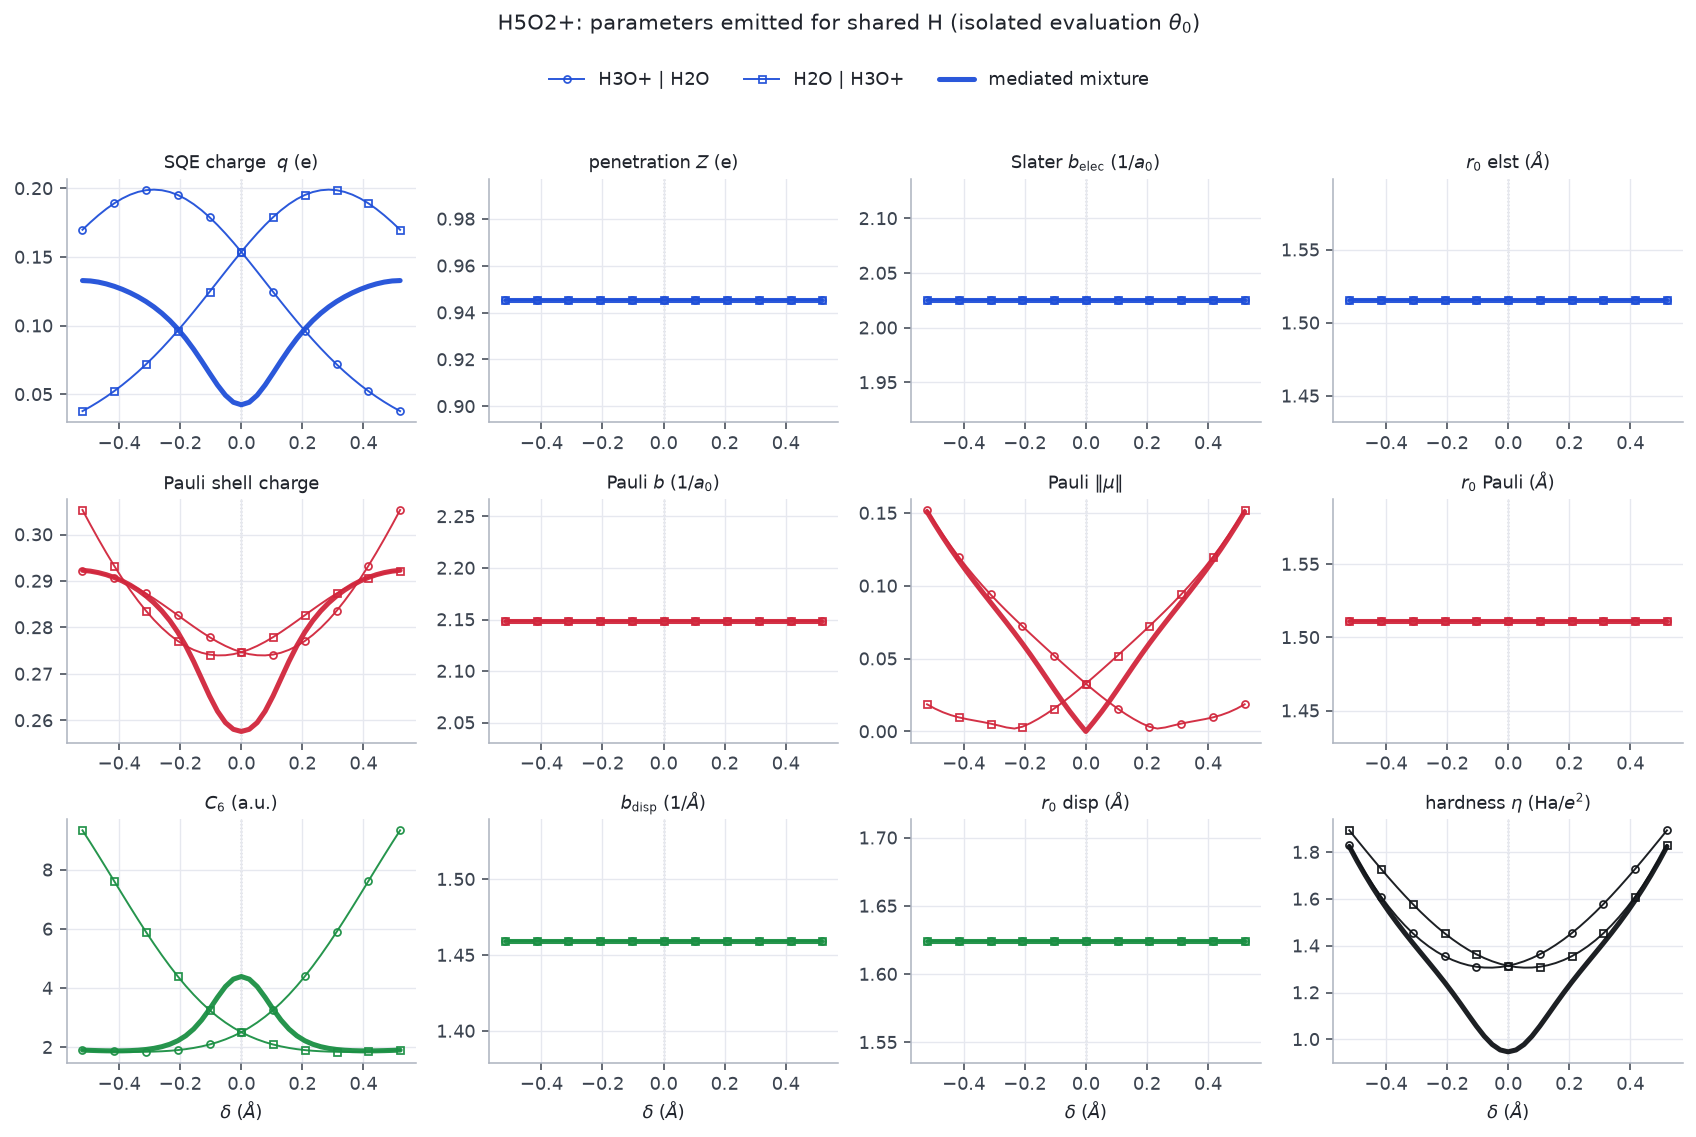

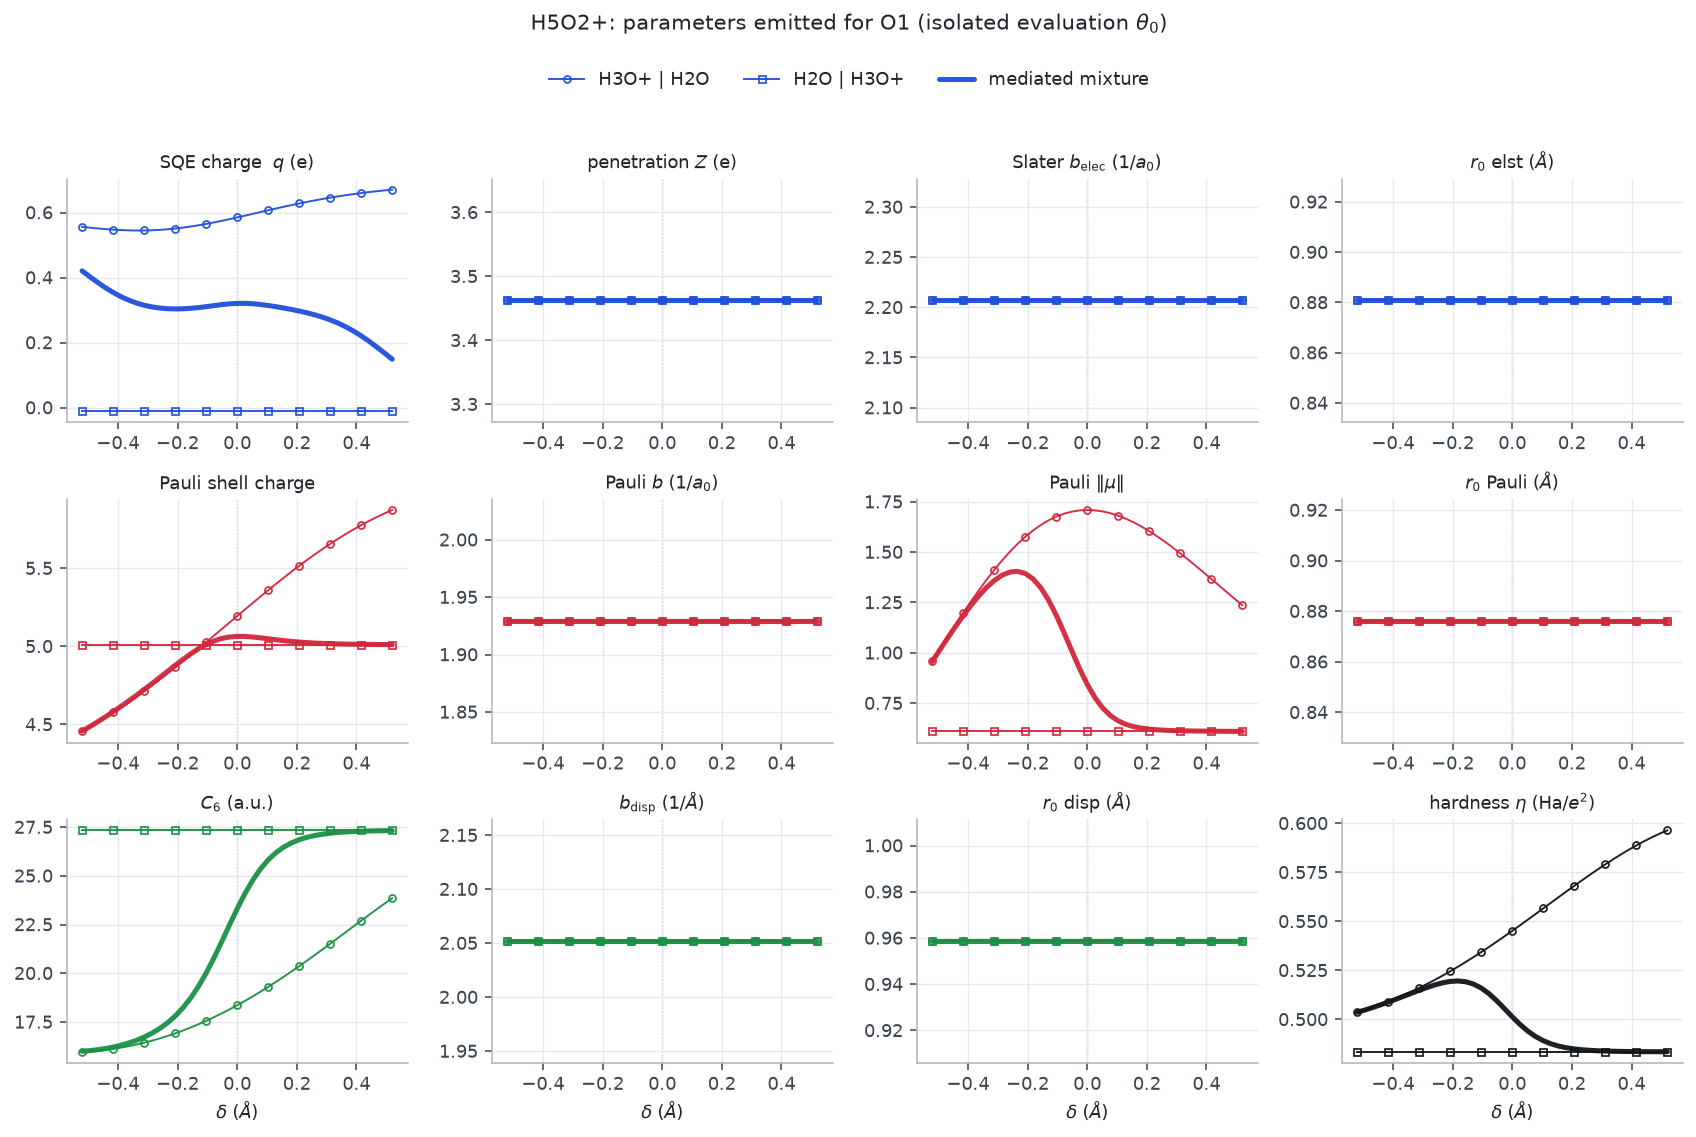

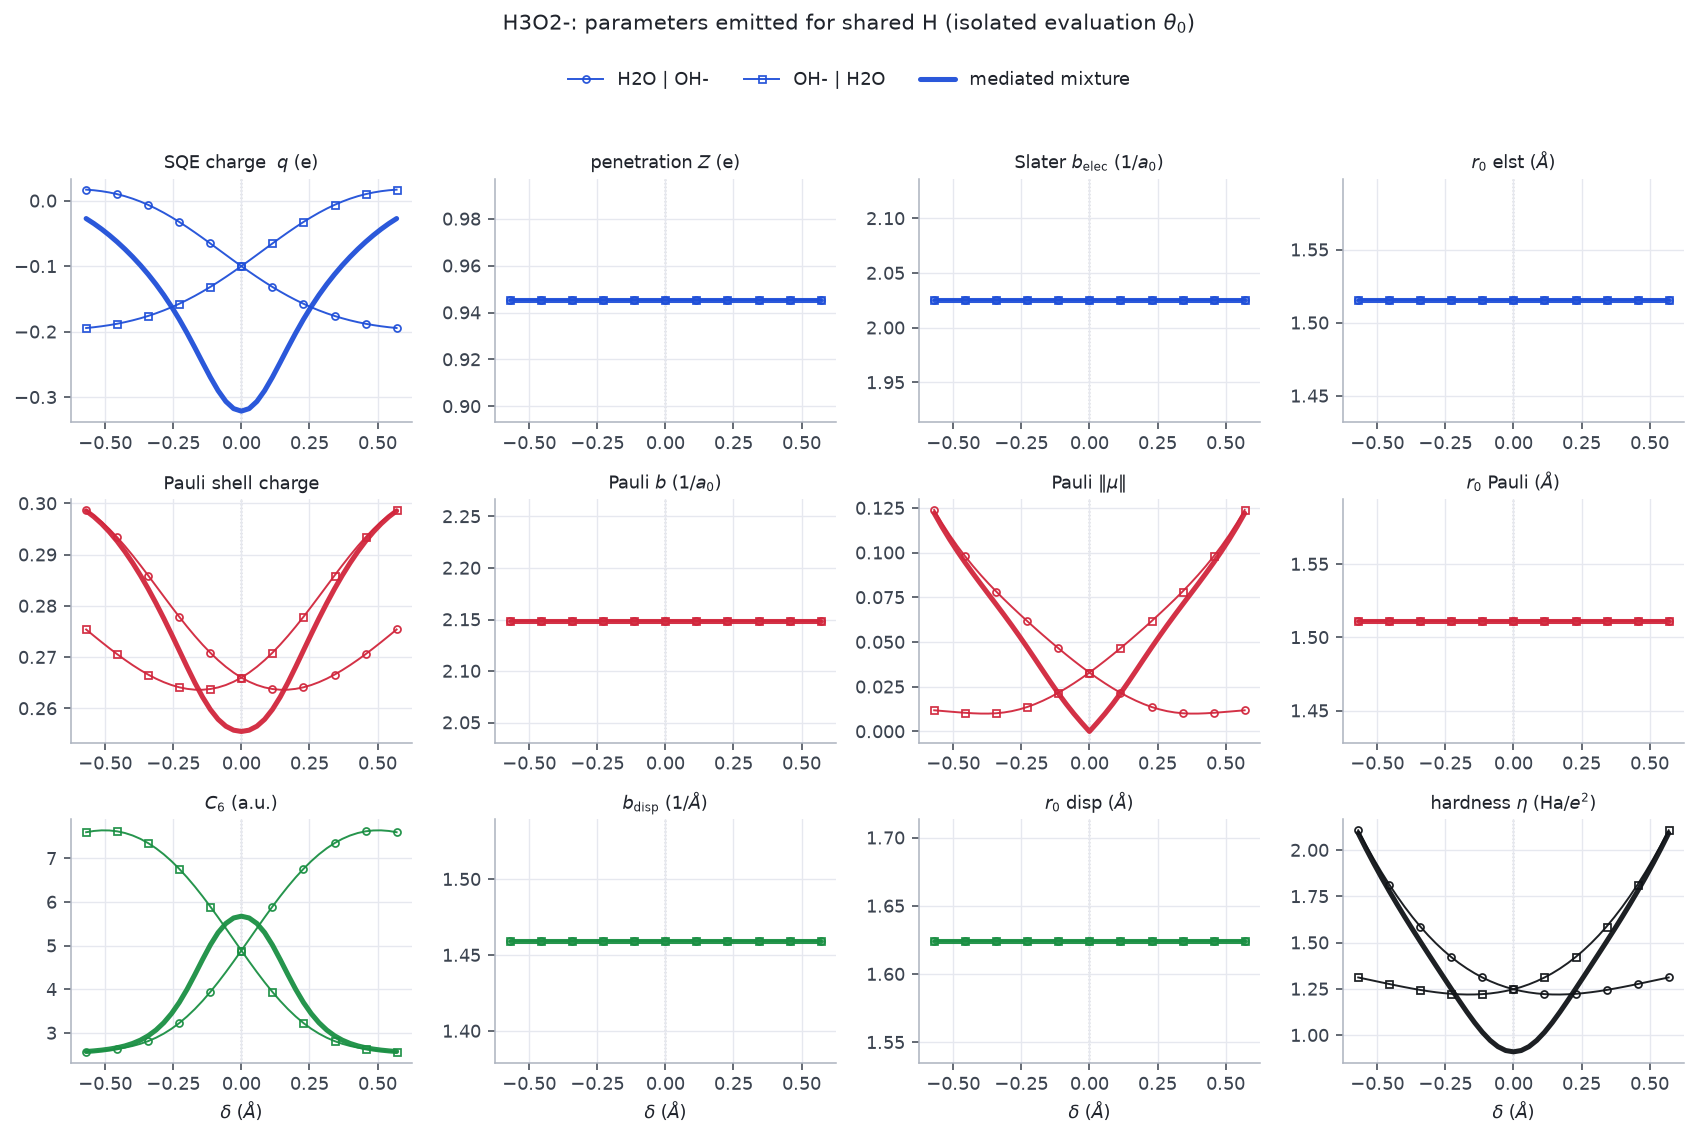

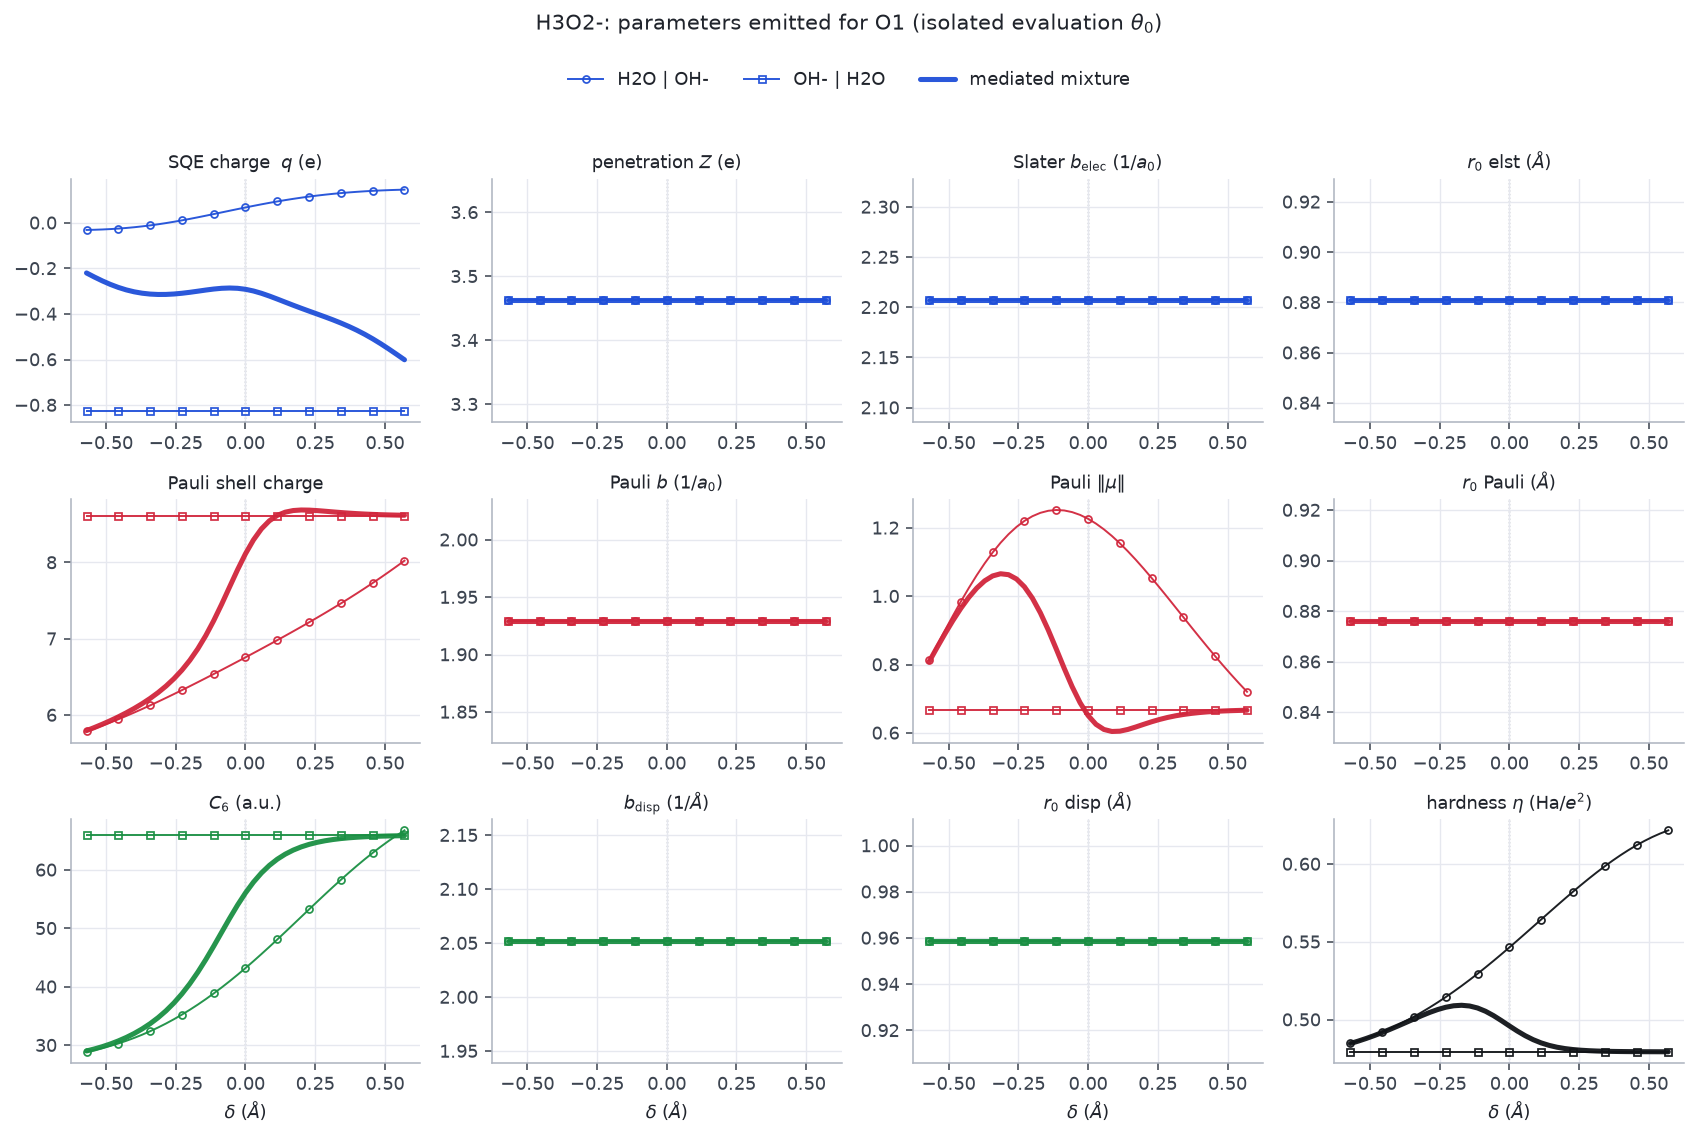

In [7]:
PARAM_PANES = [
    ("q",        "SQE charge  $q$ (e)",                    "elst"),
    ("Z",        "penetration $Z$ (e)",                     "elst"),
    ("b_elec",   "Slater $b_{\\mathrm{elec}}$ (1/$a_0$)",      "elst"),
    ("r0_elst",  "$r_0$ elst ($\\AA$)",                       "elst"),
    ("q_pauli",  "Pauli shell charge",                      "pauli"),
    ("b_pauli",  "Pauli $b$ (1/$a_0$)",                     "pauli"),
    ("mu_pauli", "Pauli $\\|\\mu\\|$",                        "pauli"),
    ("r0_pauli", "$r_0$ Pauli ($\\AA$)",                      "pauli"),
    ("C6",       "$C_6$ (a.u.)",                            "disp"),
    ("b_disp",   "$b_{\\mathrm{disp}}$ (1/$\\AA$)",             "disp"),
    ("r0_disp",  "$r_0$ disp ($\\AA$)",                       "disp"),
    ("eta",      "hardness $\\eta$ (Ha/$e^2$)",               "total"),
]


def parameter_figure(scans, save=True):
    """One figure per (system, atom). Two atoms are worth looking at and for opposite reasons.

    **The shared hydrogen** is described by the *same* expert in both partitions -- in H5O2+ it
    is in the hydronium either way, in H3O2- in the water either way -- so its per-element
    constants (`Z`, `b`, `r0`) are identical between the vertices and only the
    feature-dependent quantities move.

    **O1** is where the expert actually changes: a hydronium oxygen under one partition and a
    water oxygen under the other. That is where the per-element constants differ between
    vertices, and where the thick line is visibly a weighted average of two flat lines rather
    than a network output.
    """
    n_cols = 4
    figs = []
    cases = [(name, s, label, idx)
             for name, s in scans.items()
             for label, idx in (("shared H", SYSTEMS[name]["bridge"]),
                                ("O1", SYSTEMS[name]["o_pair"][0]))]
    for name, s, atom_label, bridge in cases:
        spec = SYSTEMS[name]
        x = s["delta"]
        n_part = spec["fragments"].shape[0]

        fig, axes = plt.subplots(3, n_cols, figsize=(3.05 * n_cols, 2.5 * 3))
        for ax, (key, title, channel) in zip(axes.ravel(), PARAM_PANES):
            color = CHANNEL_COLOR[channel]
            for m in range(n_part):
                y = np.array([float(v["params"][key][bridge]) for v in s["vertex"][m]])
                ax.plot(x, y, color=color, marker=VERTEX_MARKER[m], markevery=MARKEVERY,
                        label=spec["labels"][m] if key == "q" else None, **VERTEX_STYLE)
            ym = np.array([float(v["params"][key][bridge]) for v in s["mix"]])
            ax.plot(x, ym, color=color, label="mediated mixture" if key == "q" else None,
                    **MIX_STYLE)
            ax.axvline(0.0, color=MUTED, lw=0.7, ls=":", zorder=0)
            ax.set_title(title, color=INK, fontsize=9, pad=5)
        for ax in axes[-1]:
            ax.set_xlabel(r"$\delta$ ($\AA$)")

        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
                   bbox_to_anchor=(0.5, 1.035), labelcolor=INK)
        fig.suptitle(f"{name}: parameters emitted for {atom_label} "
                     r"(isolated evaluation $\theta_0$)", y=1.075, fontsize=11, color=INK)
        fig.tight_layout()
        if save:
            tag = name.replace("+", "p").replace("-", "m")
            atag = atom_label.replace(" ", "_")
            fig.savefig(FIGDIR / f"mediator_parameters_{tag}_{atag}.png", bbox_inches="tight")
        figs.append(fig)
    return figs


parameter_figure(scans);

## 3. The membership

`pi` against the transfer coordinate, at fixed R(O-O). This is the quantity that decides
everything above: the thick lines in figures 1 and 2 are these weights applied to the thin ones.

The dashed lines are the validity envelopes `Omega`, the C2 bump on each contact distance that
gates enumeration. Where an envelope reaches zero its candidate is closed *exactly*, not merely
unlikely, and the mixture reduces to the surviving vertex - which is Invariant 1.

By symmetry `pi` must cross at `delta = 0` for both of these systems, and the shape either side
of the crossing is the whole of what the mediator learned.

H5O2+: occupancy max 0.500 at delta=+0.000, w at delta~0 = [0.5, 0.5], fraction of scan with occupancy > 0.05: 0.46
H3O2-: occupancy max 0.500 at delta=+0.000, w at delta~0 = [0.5, 0.5], fraction of scan with occupancy > 0.05: 0.51


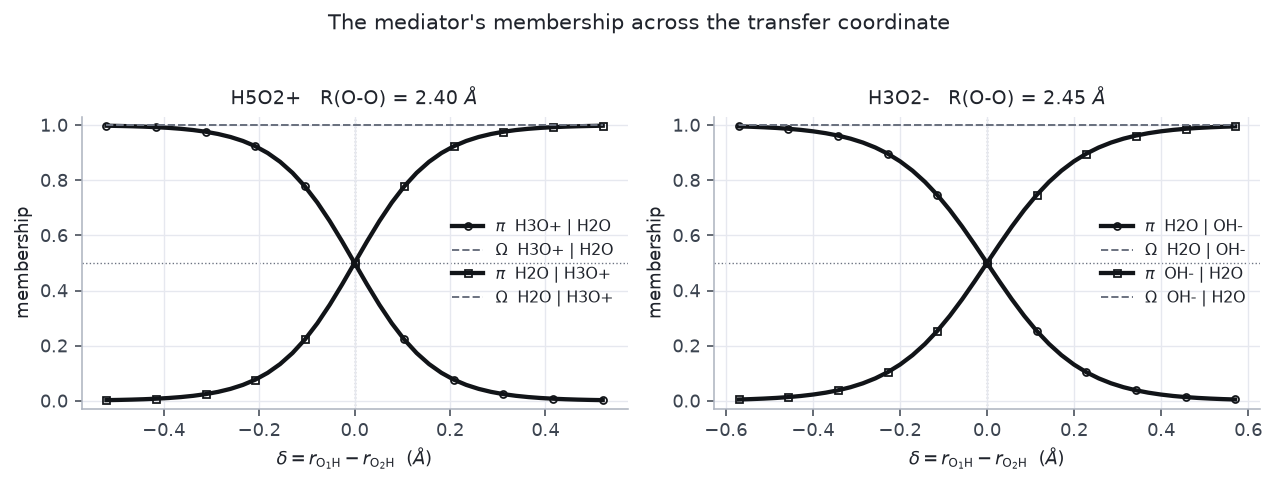

In [8]:
def membership_figure(scans, save=True):
    fig, axes = plt.subplots(1, len(scans), figsize=(4.6 * len(scans), 3.3), squeeze=False)
    for ax, (name, s) in zip(axes[0], scans.items()):
        spec = SYSTEMS[name]
        x = s["delta"]
        n_part = s["weights"].shape[1]
        for m in range(n_part):
            ax.plot(x, s["weights"][:, m], color=CHANNEL_COLOR["total"],
                    marker=VERTEX_MARKER[m], markevery=MARKEVERY,
                    label=rf"$\pi$  {spec['labels'][m]}", **{**VERTEX_STYLE, "lw": 2.2, "alpha": 1.0})
            ax.plot(x, s["omega"][:, m], color=MUTED, lw=1.0, ls="--",
                    label=r"$\Omega$  " + spec["labels"][m])
        ax.axvline(0.0, color=MUTED, lw=0.7, ls=":", zorder=0)
        ax.axhline(0.5, color=MUTED, lw=0.7, ls=":", zorder=0)
        ax.set_ylim(-0.03, 1.03)
        ax.set_title(f"{name}   R(O-O) = {spec['r_oo']:.2f} " + r"$\AA$", color=INK, fontsize=10)
        ax.set_xlabel(r"$\delta = r_{\mathrm{O_1H}} - r_{\mathrm{O_2H}}$  ($\AA$)")
        ax.set_ylabel("membership", color=INK)
        ax.legend(frameon=False, fontsize=8, labelcolor=INK, loc="center right")
    fig.suptitle("The mediator's membership across the transfer coordinate",
                 y=1.03, fontsize=11, color=INK)
    fig.tight_layout()
    if save:
        fig.savefig(FIGDIR / "mediator_membership.png", bbox_inches="tight")
    return fig


membership_figure(scans);

for name, s in scans.items():
    w = s["weights"]
    occ = 1.0 - w.max(axis=1)
    mid = np.argmin(np.abs(s["delta"]))
    print(f"{name}: occupancy max {occ.max():.3f} at delta={s['delta'][np.argmax(occ)]:+.3f}, "
          f"w at delta~0 = {np.round(w[mid], 4).tolist()}, "
          f"fraction of scan with occupancy > 0.05: {(occ > 0.05).mean():.2f}")

## 4. The crossover, resolved

Figures 1-3 put roughly **one grid point** inside the switching region, which is not an
accident of the grid: the trained mediator turns over within a few hundredths of an Angstrom.
Rerunning the same scan on a narrow window around `delta = 0` shows what is actually happening
there, and it is not a smooth interpolation.

**Mixing parameters is not mixing energies.** §8 mixes `C6`, `r0`, the Pauli multipoles and the
response parameters at the *parameter* level, on the argument that both experts emit the same
physical number. That argument is sound, but the classical forms are strongly **nonlinear** in
those numbers - a geometric mean under a square root, a Fermi gate on `r0`, a Tang-Toennies
damping - so a halfway parameter set does not produce a halfway energy. Where the two vertices
disagree about `r0`, the mixed `r0` can open a channel that *neither* vertex opens.

The `excursion` printed below measures exactly that: how far the mixture leaves the interval
spanned by the two vertices. A linear interpolation would give zero.

This is also, most likely, *why* the mediator learned to switch so sharply. A wide crossover
would park the model in this region, and the region is expensive; sharpening `pi` is the
cheapest way to avoid it. That reading is consistent with `pi_split` collapsing to ~0.002
during training, and it means the near-one-hot membership is not only a property of the data.

excursion beyond the vertex interval, kJ/mol (0 would mean the mixture interpolates)

  H5O2+
    electrostatics            141.13
    Pauli                     166.04
    dispersion                  3.08
    induction (pol + CT)       37.08
    total energy              171.40
    switching width (occupancy > 0.05): 0.240 A

  H3O2-
    electrostatics            200.30
    Pauli                     129.76
    dispersion                  6.08
    induction (pol + CT)      151.78
    total energy               38.74
    switching width (occupancy > 0.05): 0.240 A



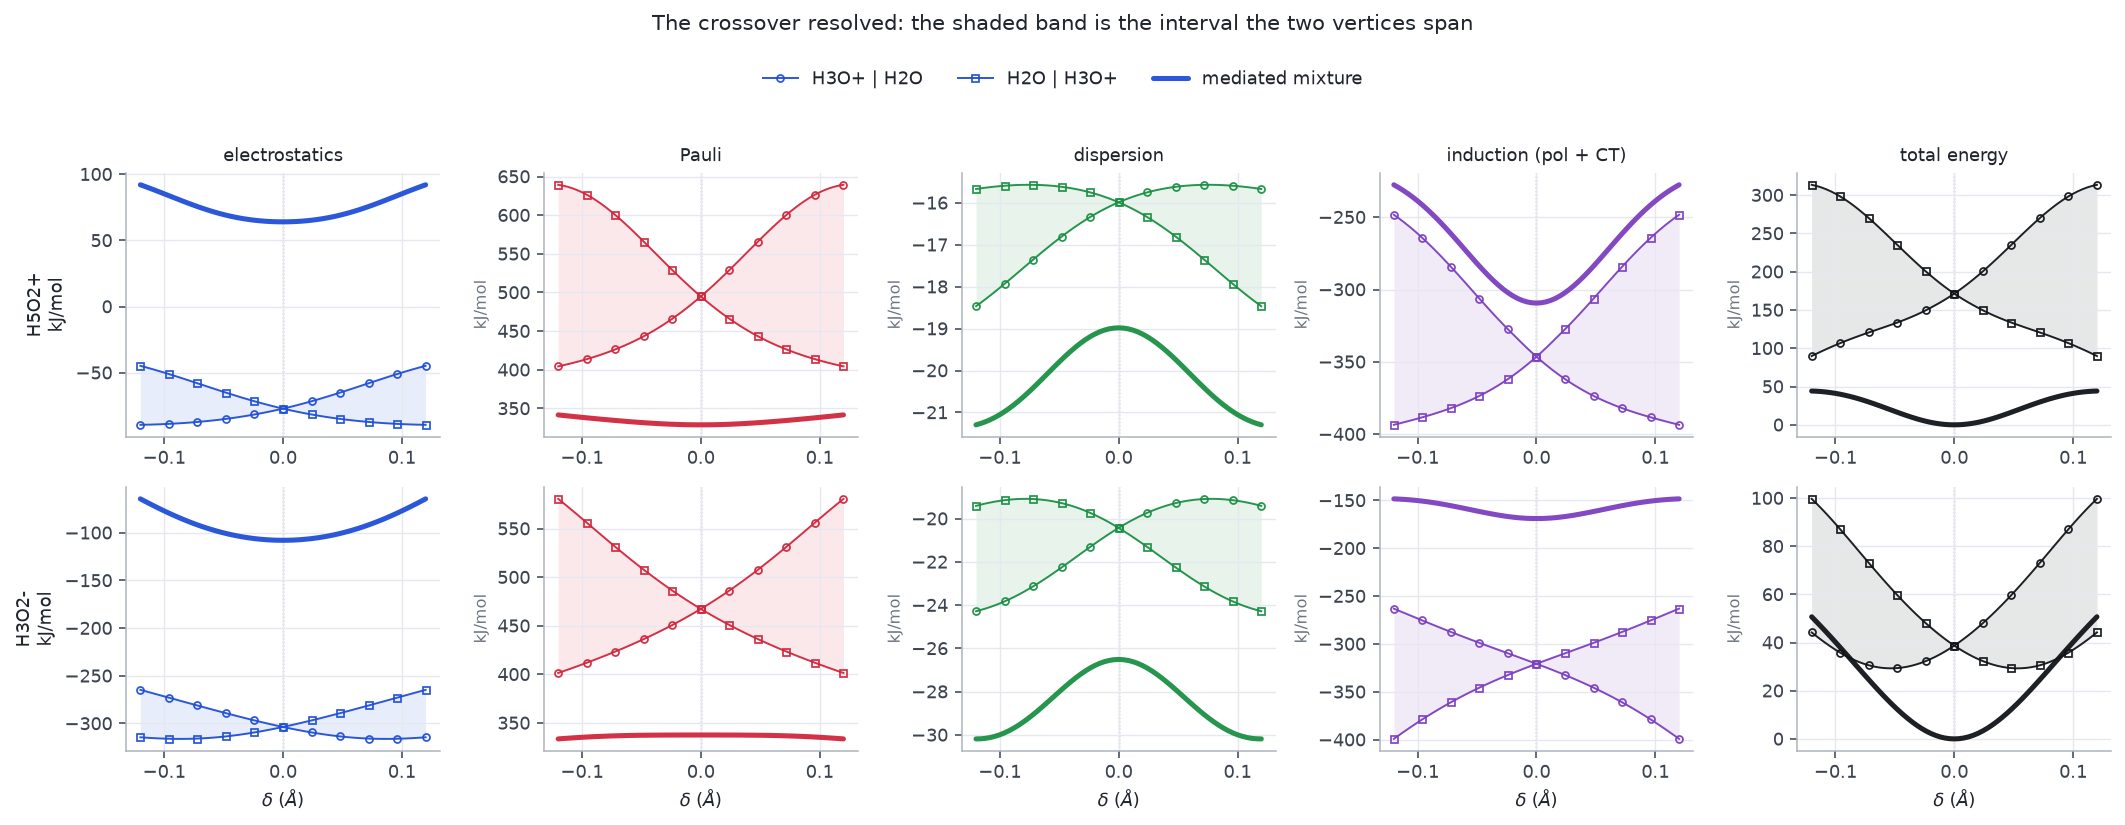

In [9]:
ZOOM = {name: scan(name, n=61, delta_window=(-0.12, 0.12)) for name in SYSTEMS}


def crossover_figure(zoom, save=True):
    fig, axes = plt.subplots(len(zoom), len(CHANNELS),
                             figsize=(3.05 * len(CHANNELS), 2.65 * len(zoom)))
    axes = np.atleast_2d(axes)
    for r, (name, s) in enumerate(zoom.items()):
        spec = SYSTEMS[name]
        x = s["delta"]
        n_part = spec["fragments"].shape[0]
        for c, (key, title) in enumerate(CHANNELS):
            ax = axes[r, c]
            color = CHANNEL_COLOR[key]
            series = [np.array([v["energy"][key] for v in s["vertex"][m]]) * KJMOL_PER_HARTREE
                      for m in range(n_part)]
            mixed = np.array([v["energy"][key] for v in s["mix"]]) * KJMOL_PER_HARTREE
            if key == "total":
                floor = min(min(v.min() for v in series), mixed.min())
                series = [v - floor for v in series]
                mixed = mixed - floor
            for m in range(n_part):
                ax.plot(x, series[m], color=color, marker=VERTEX_MARKER[m], markevery=6,
                        label=spec["labels"][m] if (r == 0 and c == 0) else None, **VERTEX_STYLE)
            ax.plot(x, mixed, color=color,
                    label="mediated mixture" if (r == 0 and c == 0) else None, **MIX_STYLE)
            # Shade the band the two vertices span: the mixture leaving it is the defect.
            ax.fill_between(x, np.minimum(*series), np.maximum(*series),
                            color=color, alpha=0.10, linewidth=0)
            ax.axvline(0.0, color=MUTED, lw=0.7, ls=":", zorder=0)
            if r == 0:
                ax.set_title(title, color=INK, fontsize=9.5, pad=6)
            ax.set_ylabel(f"{name}\nkJ/mol" if c == 0 else "kJ/mol",
                          color=INK if c == 0 else MUTED, fontsize=9 if c == 0 else 8)
            if r == len(zoom) - 1:
                ax.set_xlabel(r"$\delta$ ($\AA$)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 1.045), labelcolor=INK)
    fig.suptitle("The crossover resolved: the shaded band is the interval the two vertices span",
                 y=1.10, fontsize=11, color=INK)
    fig.tight_layout()
    if save:
        fig.savefig(FIGDIR / "mediator_crossover.png", bbox_inches="tight")
    return fig


crossover_figure(ZOOM);

print("excursion beyond the vertex interval, kJ/mol (0 would mean the mixture interpolates)\n")
for name, s in ZOOM.items():
    n_part = SYSTEMS[name]["fragments"].shape[0]
    print(f"  {name}")
    for key, title in CHANNELS:
        series = [np.array([v["energy"][key] for v in s["vertex"][m]]) * KJMOL_PER_HARTREE
                  for m in range(n_part)]
        mixed = np.array([v["energy"][key] for v in s["mix"]]) * KJMOL_PER_HARTREE
        lo, hi = np.minimum(*series), np.maximum(*series)
        excursion = np.maximum(lo - mixed, mixed - hi).max()
        print(f"    {title:22s} {excursion:9.2f}")

    w = s["weights"]
    occ = 1.0 - w.max(axis=1)
    wide = s["delta"][occ > 0.05]
    width = (wide.max() - wide.min()) if wide.size else 0.0
    print(f"    switching width (occupancy > 0.05): {width:.3f} A\n")

## 5. The one-body side: bond energies and the intra/inter boundary

Figures 1 and 4 show the *inter* channels. The routing weight `b_ij` moves pairs **across** the
intra/inter boundary, so whatever leaves one bucket enters the other, and the one-body side has
to show the mirror image. This is that half.

`E_bond` is per **atom** by construction -- `FragmentBondEnergy` emits a per-atom scalar which
the model pools to the fragment -- so there is no per-bond decomposition to plot. An O-H bond
appears here through the two atoms it joins, which is why the first three panes are O1, O2 and
the shared H rather than a bond list.

The `O1-H` and `O2-H` panes are the intra-fragment **classical pair energy** on those two
contacts: the quantity that literally crosses the boundary as the membership moves. Their
`b_ij` is plotted underneath, and it is the accounting made visible -- at a vertex each contact
is fully intra (1) for one host and fully inter (0) for the other.

one-body totals at the crossover, kJ/mol

  H5O2+   bond   excursion   107.28
  H5O2+   intra  excursion    76.90
  H3O2-   bond   excursion    98.27
  H3O2-   intra  excursion    18.99


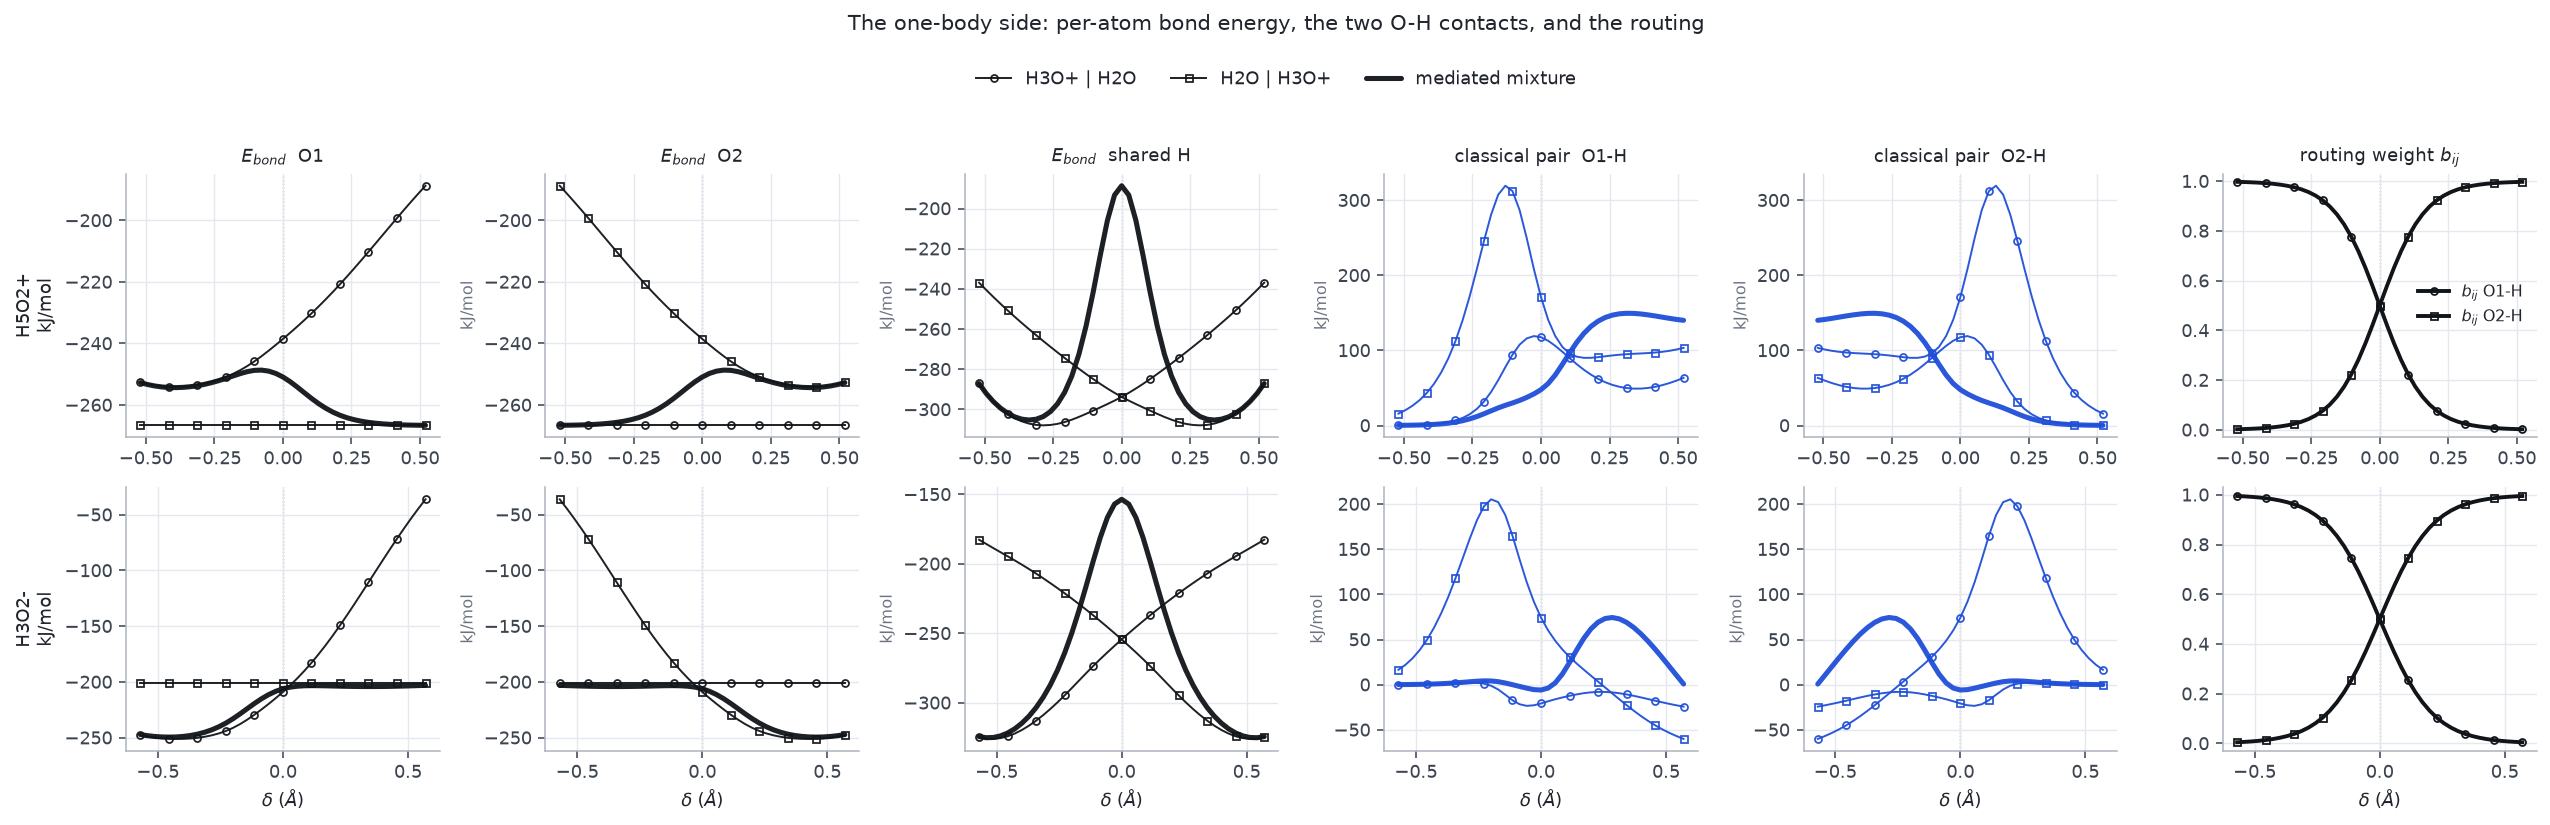

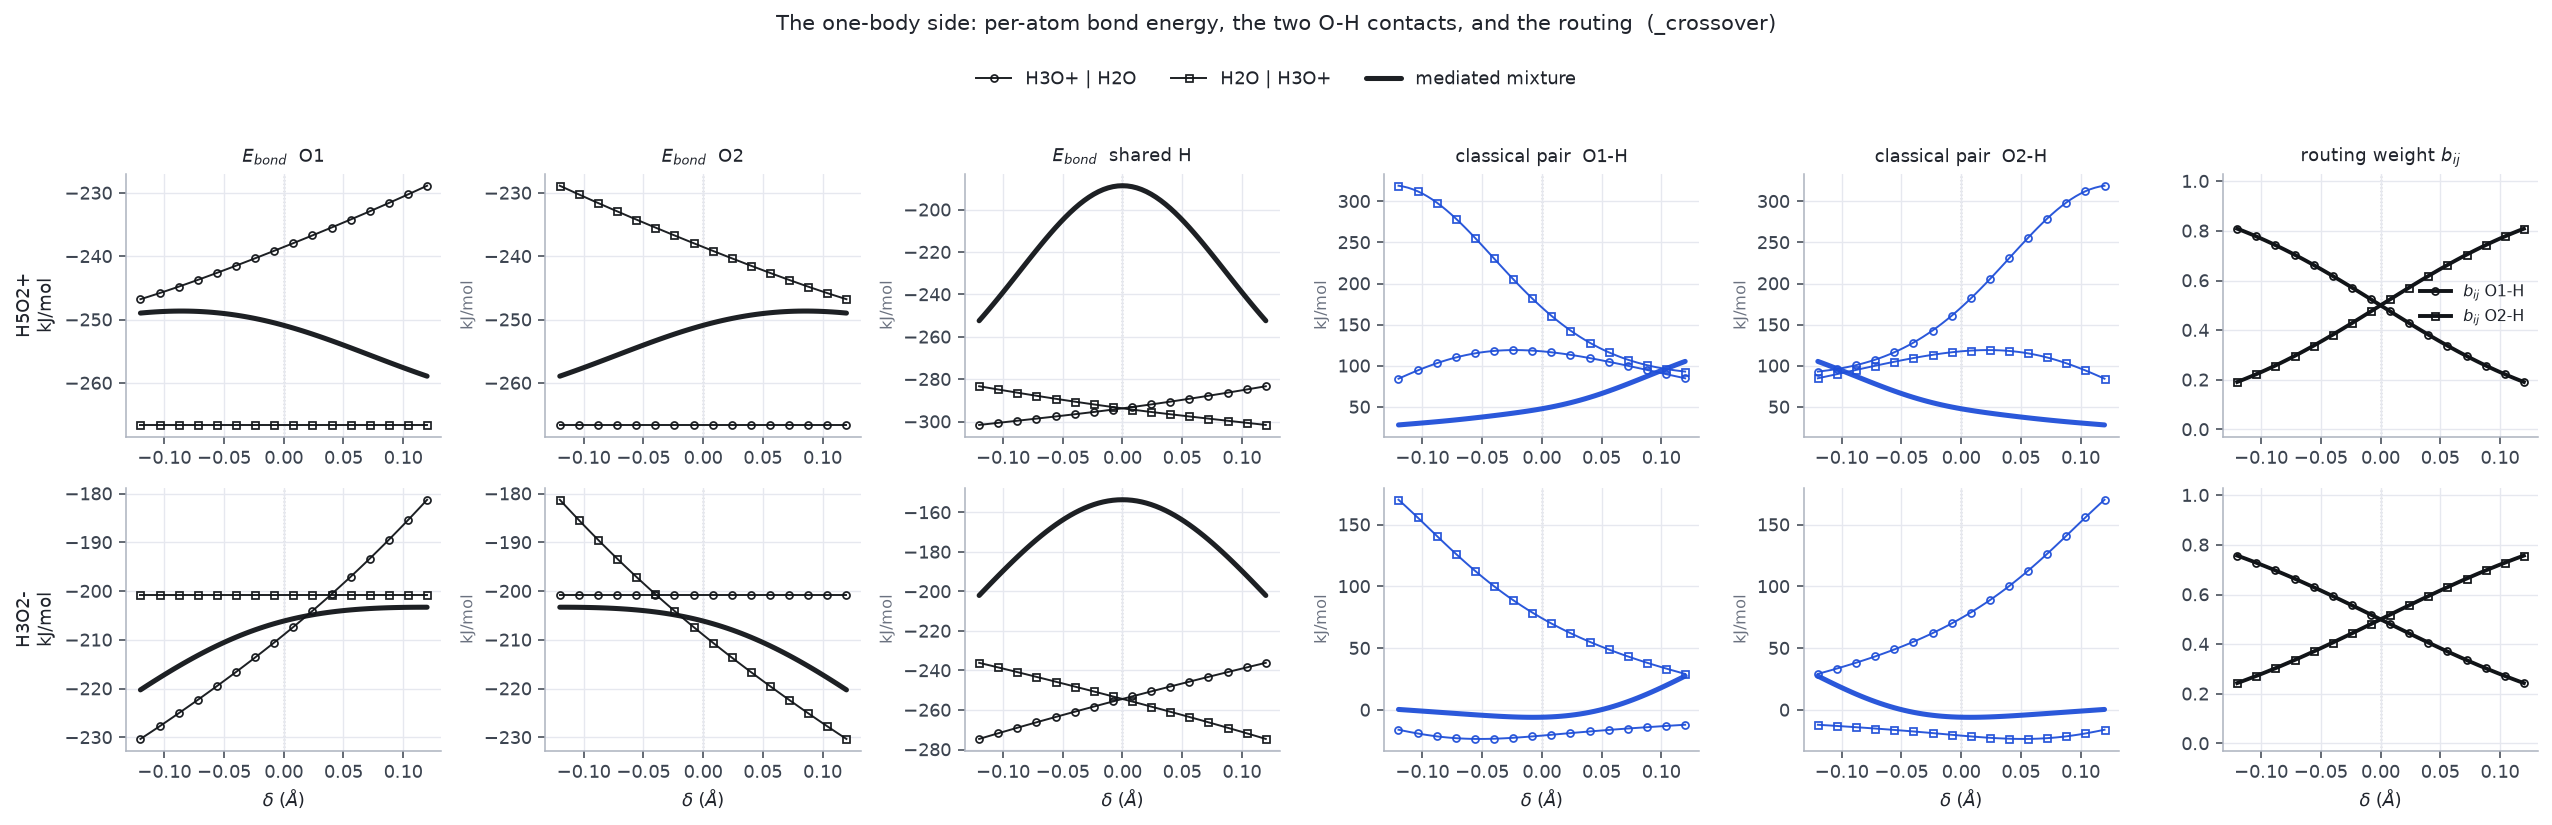

In [10]:
def bond_figure(scans, tag="", save=True):
    n_rows = len(scans)
    fig, axes = plt.subplots(n_rows, 6, figsize=(3.05 * 6, 2.65 * n_rows))
    axes = np.atleast_2d(axes)
    black = CHANNEL_COLOR["total"]

    for r, (name, s) in enumerate(scans.items()):
        spec = SYSTEMS[name]
        x = s["delta"]
        n_part = spec["fragments"].shape[0]
        atoms = [("O1", spec["o_pair"][0]), ("O2", spec["o_pair"][1]), ("shared H", spec["bridge"])]

        for c, (label, idx) in enumerate(atoms):
            ax = axes[r, c]
            for m in range(n_part):
                y = np.array([float(v["bond_atom"][idx]) for v in s["vertex"][m]]) * KJMOL_PER_HARTREE
                ax.plot(x, y, color=black, marker=VERTEX_MARKER[m], markevery=MARKEVERY,
                        label=spec["labels"][m] if (r == 0 and c == 0) else None, **VERTEX_STYLE)
            ym = np.array([float(v["bond_atom"][idx]) for v in s["mix"]]) * KJMOL_PER_HARTREE
            ax.plot(x, ym, color=black,
                    label="mediated mixture" if (r == 0 and c == 0) else None, **MIX_STYLE)
            if r == 0:
                ax.set_title(f"$E_{{bond}}$  {label}", color=INK, fontsize=9.5, pad=6)

        # the two O-H contacts: intra classical pair energy, and the routing weight under it
        for c, key in enumerate(("O1-H", "O2-H"), start=3):
            ax = axes[r, c]
            for m in range(n_part):
                y = np.array([v["pairs"][key][0] for v in s["vertex"][m]]) * KJMOL_PER_HARTREE
                ax.plot(x, y, color=CHANNEL_COLOR["elst"], marker=VERTEX_MARKER[m],
                        markevery=MARKEVERY, **VERTEX_STYLE)
            ym = np.array([v["pairs"][key][0] for v in s["mix"]]) * KJMOL_PER_HARTREE
            ax.plot(x, ym, color=CHANNEL_COLOR["elst"], **MIX_STYLE)
            if r == 0:
                ax.set_title(f"classical pair  {key}", color=INK, fontsize=9.5, pad=6)

        ax = axes[r, 5]
        for c, key in enumerate(("O1-H", "O2-H")):
            b = np.array([v["pairs"][key][1] for v in s["mix"]])
            ax.plot(x, b, color=black, marker=VERTEX_MARKER[c], markevery=MARKEVERY,
                    label=f"$b_{{ij}}$ {key}" if r == 0 else None,
                    **{**VERTEX_STYLE, "lw": 2.0, "alpha": 1.0})
        ax.set_ylim(-0.03, 1.03)
        if r == 0:
            ax.set_title("routing weight $b_{ij}$", color=INK, fontsize=9.5, pad=6)
            ax.legend(frameon=False, fontsize=8, labelcolor=INK, loc="center right")

        for c in range(6):
            axes[r, c].axvline(0.0, color=MUTED, lw=0.7, ls=":", zorder=0)
            axes[r, c].set_ylabel(f"{name}\nkJ/mol" if c == 0 else ("kJ/mol" if c < 5 else ""),
                                  color=INK if c == 0 else MUTED, fontsize=9 if c == 0 else 8)
            if r == n_rows - 1:
                axes[r, c].set_xlabel(r"$\delta$ ($\AA$)")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 1.045), labelcolor=INK)
    fig.suptitle("The one-body side: per-atom bond energy, the two O-H contacts, and the routing"
                 + (f"  ({tag})" if tag else ""), y=1.10, fontsize=11, color=INK)
    fig.tight_layout()
    if save:
        fig.savefig(FIGDIR / f"mediator_bond{tag}.png", bbox_inches="tight")
    return fig


bond_figure(scans)
bond_figure(ZOOM, tag="_crossover");

print("one-body totals at the crossover, kJ/mol\n")
for name, s in ZOOM.items():
    n_part = SYSTEMS[name]["fragments"].shape[0]
    for which in ("bond", "intra"):
        series = [np.array([v["totals"][which] for v in s["vertex"][m]]) * KJMOL_PER_HARTREE
                  for m in range(n_part)]
        mixed = np.array([v["totals"][which] for v in s["mix"]]) * KJMOL_PER_HARTREE
        lo, hi = np.minimum(*series), np.maximum(*series)
        print(f"  {name:7s} {which:6s} excursion {np.maximum(lo - mixed, mixed - hi).max():8.2f}")